**TASK 2 - EXPLORATORY DATA ANALYSIS**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_online_retail II.csv to cleaned_online_retail II.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("cleaned_online_retail II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,cancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1027022 entries, 0 to 1027021
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1027022 non-null  object 
 1   StockCode    1027022 non-null  object 
 2   Description  1027022 non-null  object 
 3   Quantity     1027022 non-null  int64  
 4   InvoiceDate  1027022 non-null  object 
 5   Price        1027022 non-null  float64
 6   Customer ID  797815 non-null   float64
 7   Country      1027022 non-null  object 
 8   cancelled    1027022 non-null  bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 63.7+ MB


In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],errors = 'coerce')

In [7]:
df.info() #Converting Date column from object to datetime

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1027022 entries, 0 to 1027021
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1027022 non-null  object        
 1   StockCode    1027022 non-null  object        
 2   Description  1027022 non-null  object        
 3   Quantity     1027022 non-null  int64         
 4   InvoiceDate  1027022 non-null  datetime64[ns]
 5   Price        1027022 non-null  float64       
 6   Customer ID  797815 non-null   float64       
 7   Country      1027022 non-null  object        
 8   cancelled    1027022 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 63.7+ MB


In [8]:
df['Revenue'] = df['Quantity'] * df['Price'] #Revenue Calculation

In [9]:
df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


Monthly Revenue Trend

In [10]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M') #converting invoice date to year and month
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum() #monthly revenue
monthly_revenue

,Revenue
YearMonth,
2009-12,796648.500
2010-01,622479.502
2010-02,531265.366
2010-03,763247.241
2010-04,587926.692
2010-05,613270.720
2010-06,677073.870
2010-07,573333.690
2010-08,654774.390


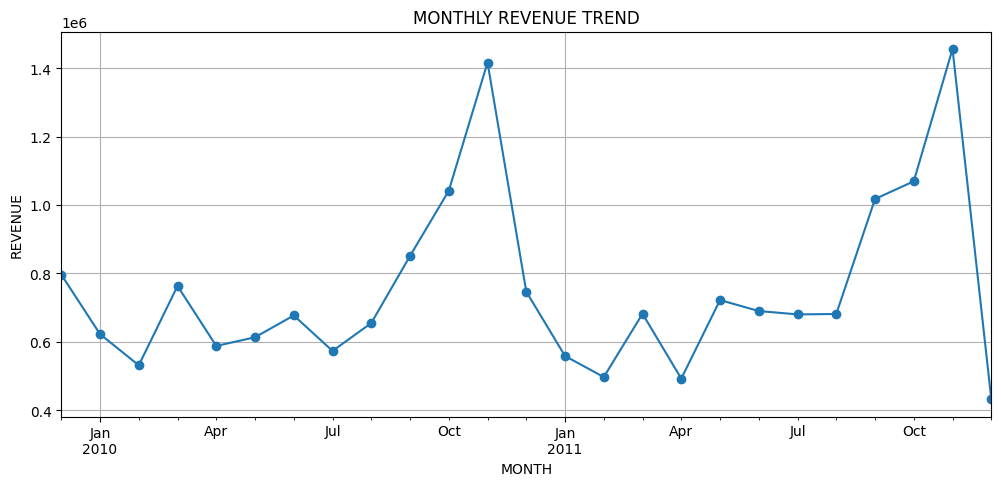

In [11]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind='line', marker = 'o', figsize=(12,5))
plt.title("MONTHLY REVENUE TREND")
plt.xlabel("MONTH")
plt.ylabel("REVENUE")
plt.grid(True)
plt.show()

Top Products by Quantity

In [12]:
top_products_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head()#sorting the top products
top_products_quantity

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,104435
WHITE HANGING HEART T-LIGHT HOLDER,91021
ASSORTED COLOUR BIRD ORNAMENT,79571
JUMBO BAG RED RETROSPOT,76508
BROCADE RING PURSE,69629


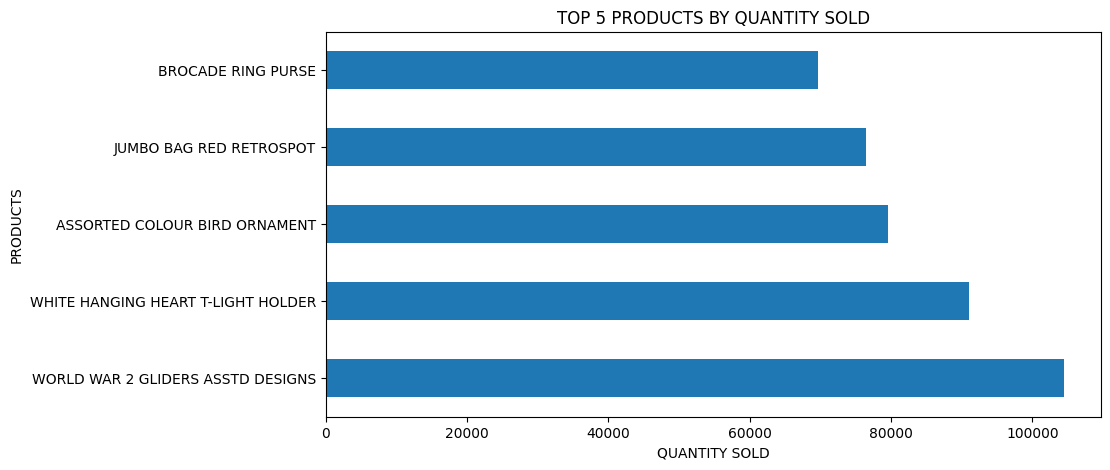

In [13]:
import matplotlib.pyplot as plt

top_products_quantity.plot(kind = 'barh', figsize=(10,5))
plt.title("TOP 5 PRODUCTS BY QUANTITY SOLD")
plt.xlabel("QUANTITY SOLD")
plt.ylabel("PRODUCTS")
plt.show()

Top 5 Countries By Revenue

In [14]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head()#sorting the top country
country_revenue

,Revenue
Country,
United Kingdom,1.598606e+07
EIRE,6.099538e+05
Netherlands,5.483307e+05
Germany,4.119592e+05
France,3.217334e+05


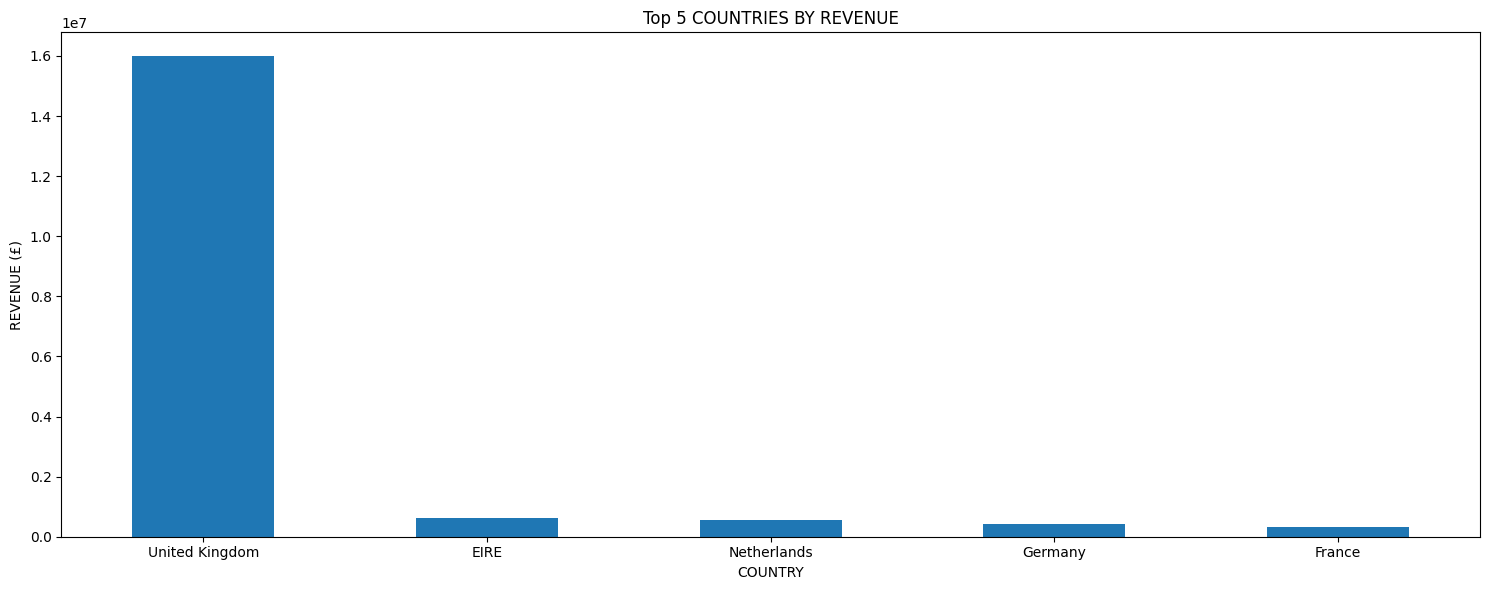

In [15]:
import matplotlib.pyplot as plt

country_revenue.plot(kind='bar',figsize=(15,6))

plt.title("Top 5 COUNTRIES BY REVENUE")
plt.xlabel("COUNTRY")
plt.ylabel("REVENUE (£)")
plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [16]:
total_revenue = df['Revenue'].sum()#total revenue generated
total_revenue

np.float64(18855533.69800001)

Top 5 Countries By Revenue Shares

In [17]:
country_shares = (df.groupby('Country')['Revenue'].sum() / total_revenue * 100).sort_values(ascending=False).head()#calculating countries shares
country_shares

,Revenue
Country,
United Kingdom,84.781797
EIRE,3.234879
Netherlands,2.908062
Germany,2.184818
France,1.706308


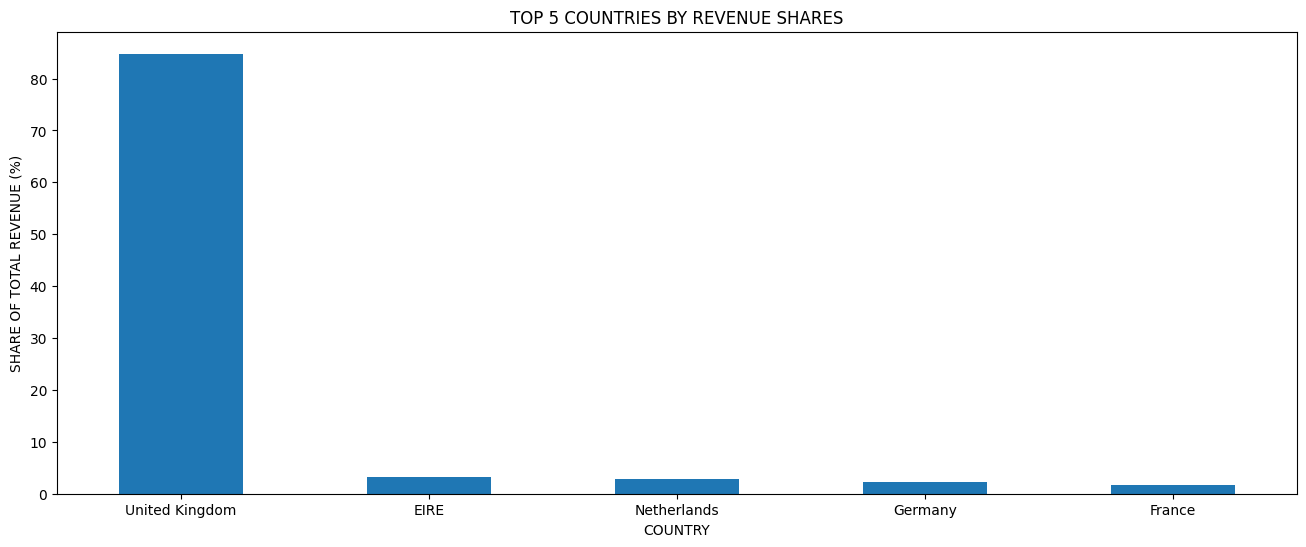

In [18]:
import matplotlib.pyplot as plt

country_shares.plot(kind='bar',figsize=(16,6))

plt.title("TOP 5 COUNTRIES BY REVENUE SHARES")
plt.xlabel("COUNTRY")
plt.ylabel("SHARE OF TOTAL REVENUE (%)")
plt.xticks(rotation=0)

plt.show()

Top 10% vs Other Customers

In [19]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)#calculating customers revenue
customer_revenue

,Revenue
Customer ID,
18102.0,570380.61
14646.0,523342.07
14156.0,296063.44
14911.0,265757.91
17450.0,231390.55
...,...
16981.0,-4620.86
15760.0,-5795.87
15849.0,-5876.34


In [20]:
top_10pct_count = int(len(customer_revenue)*0.10)
top_10pct_count

593

In [21]:
top_10pct_revenue = customer_revenue.head(top_10pct_count).sum()
top_10pct_revenue

np.float64(10370432.658)

In [22]:
top_10pct_share = top_10pct_revenue / total_revenue * 100
top_10pct_share

np.float64(54.99941197156346)

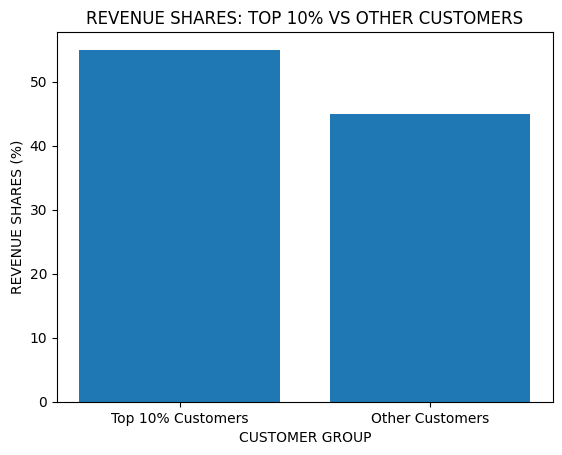

In [23]:
import matplotlib.pyplot as plt

customer_groups = ['Top 10% Customers', 'Other Customers']

customer_shares = [top_10pct_share, 100 - top_10pct_share]

plt.bar(customer_groups, customer_shares)

plt.title('REVENUE SHARES: TOP 10% VS OTHER CUSTOMERS')
plt.xlabel('CUSTOMER GROUP')
plt.ylabel('REVENUE SHARES (%)')

plt.show()

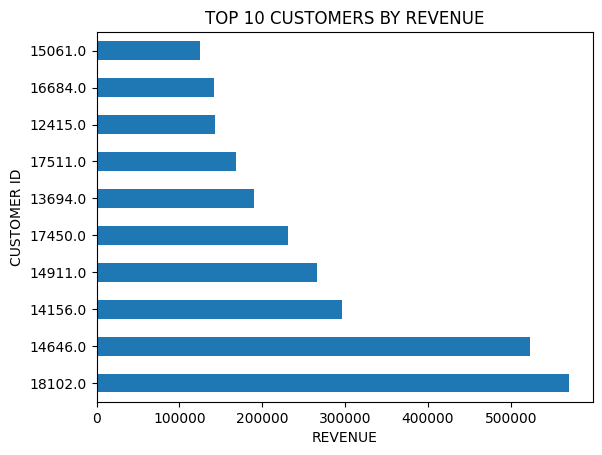

In [24]:
import matplotlib.pyplot as plt

top_10_customers = customer_revenue.head(10)

top_10_customers.plot(kind='barh')

plt.title('TOP 10 CUSTOMERS BY REVENUE')
plt.xlabel('REVENUE')
plt.ylabel('CUSTOMER ID')

plt.show()

In [25]:
cancelled_revenue = df[df['cancelled'] == True]['Revenue'].sum()
cancelled_revenue

np.float64(-1462050.6099999999)

In [26]:
cancelled_shares = abs(cancelled_revenue) / total_revenue * 100
cancelled_shares

np.float64(7.753960367375219)

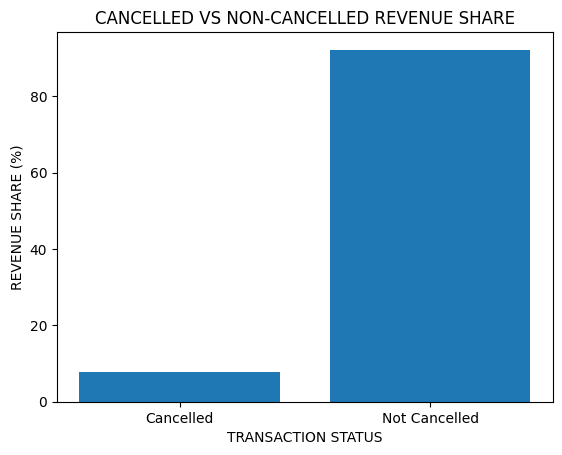

In [27]:
import matplotlib.pyplot as plt

cancellation_groups = ['Cancelled', 'Not Cancelled']

cancellation_shares = [cancelled_shares, 100 - cancelled_shares]

plt.bar(cancellation_groups, cancellation_shares)

plt.title('CANCELLED VS NON-CANCELLED REVENUE SHARE')
plt.xlabel('TRANSACTION STATUS')
plt.ylabel('REVENUE SHARE (%)')

plt.show()